# HealthGuard Patient Readmission Prediction
## Activity 2 Practical Implementation

## 1. Dataset Loading and Initial Exploration

In this section, the diabetic patient dataset is loaded into Jupyter Notebook and examined to understand its structure, size, feature types, and target variable. This step is necessary before performing preprocessing and machine learning implementation.

Importing libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


 Loading dataset


In [11]:
# Load dataset
df = pd.read_csv(r"C:\Users\kumar\Downloads\diabetic_data.csv")

# Display first 5 rows
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


Basic dataset inspection

In [12]:
# Check shape of dataset
print("Dataset shape:", df.shape)

# Check column names
print("\nColumns in dataset:\n")
print(df.columns.tolist())

Dataset shape: (101766, 50)

Columns in dataset:

['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


Missing values table

In [51]:
# Check missing values before preprocessing
missing_values = df.isnull().sum()
missing_values.sort_values(ascending=False).head(10)

race             0
glimepiride      0
glipizide        0
glyburide        0
tolbutamide      0
pioglitazone     0
rosiglitazone    0
acarbose         0
miglitol         0
troglitazone     0
dtype: int64

Checking data types and missing values

In [13]:
# General information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [14]:
# Check missing after processing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

Series([], dtype: int64)

Checking unique values in target column

In [15]:
# Target column analysis
print("Unique values in 'readmitted' column:")
print(df['readmitted'].value_counts())

Unique values in 'readmitted' column:
NO     54864
>30    35545
<30    11357
Name: readmitted, dtype: int64


Initial statistical summary

In [16]:
# Summary statistics for numerical columns
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


Check duplicate records

In [17]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


Replace ? with NaN

This dataset usually contains ? as hidden missing values, so this step is very important.

In [23]:
# Replace ? with NaN
df.replace('?', np.nan, inplace=True)

# Check missing values again
missing_after_replace = df.isnull().sum()
missing_after_replace[missing_after_replace > 0].sort_values(ascending=False)

race      2273
diag_3    1423
diag_2     358
diag_1      21
dtype: int64

Drop useless columns

In [28]:
# Drop ID columns that are not useful for prediction
# errors='ignore' prevents error if the column is not present

df.drop(['encounter_id', 'patient_nbr'], axis=1, errors='ignore', inplace=True)

# Check remaining columns
print("Columns after dropping ID columns:")
print(len(df.columns))

Columns after dropping ID columns:
45


Drop columns with too many missing values

In [29]:
# Drop columns with very high missing values
# These columns contain too many missing records and may reduce model performance

df.drop(['weight', 'payer_code', 'medical_specialty'], axis=1, errors='ignore', inplace=True)

# Confirm columns removed
print("Remaining columns after removing high-missing-value columns:")
print(len(df.columns))

Remaining columns after removing high-missing-value columns:
45


convert target variable

In [30]:
# Convert target variable 'readmitted' into binary values
# 1 = patient was readmitted
# 0 = patient was not readmitted

df['readmitted'] = df['readmitted'].replace({
    '<30': 1,
    '>30': 1,
    'NO': 0
})

# Check new distribution of target variable
print(df['readmitted'].value_counts())

0    54864
1    46902
Name: readmitted, dtype: int64


encode categorical features

In [32]:
# Convert categorical columns into numerical values using Label Encoding
# Machine learning algorithms require numerical input

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

print("Categorical columns encoded successfully.")

Categorical columns encoded successfully.


define features and target

In [33]:
# Separate features (X) and target variable (y)

X = df.drop('readmitted', axis=1)
y = df['readmitted']

print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

Feature matrix shape: (101766, 44)
Target variable shape: (101766,)


train-test split

In [35]:
# Split dataset into training and testing sets
# 80% for training the model
# 20% for testing the model

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (81412, 44)
Testing data shape: (20354, 44)


In [36]:
X_train.shape
X_test.shape
df['readmitted'].value_counts()

0    54864
1    46902
Name: readmitted, dtype: int64

Logistic Regression Model

In [37]:
# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Create the model
log_model = LogisticRegression(max_iter=1000)

# Train the model using training data
log_model.fit(X_train, y_train)

# Predict using the test data
y_pred_log = log_model.predict(X_test)

# Evaluate model accuracy
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.6145229438930923


Decision Tree Model

In [38]:
# Import Decision Tree model
from sklearn.tree import DecisionTreeClassifier

# Create the model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Predict test data
y_pred_dt = dt_model.predict(X_test)

# Evaluate accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.5602829910582686


Random Forest Model

In [39]:
# Import Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.6383511840424486


Confusion Matrix

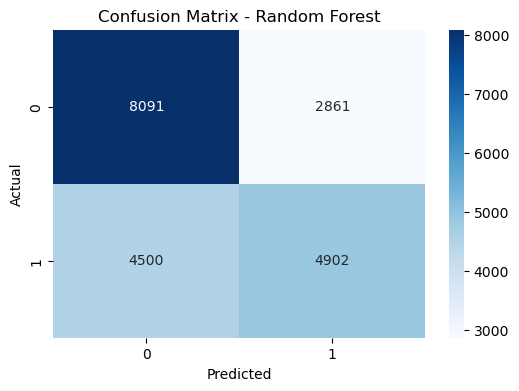

In [40]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Model Comparison Table

In [41]:
print("Model Accuracy Comparison")
print("--------------------------")
print("Logistic Regression:", log_accuracy)
print("Decision Tree:", dt_accuracy)
print("Random Forest:", rf_accuracy)

Model Accuracy Comparison
--------------------------
Logistic Regression: 0.6145229438930923
Decision Tree: 0.5602829910582686
Random Forest: 0.6383511840424486


Detailed Evaluation

In [42]:
# Detailed classification report for Random Forest

print("Random Forest Classification Report\n")

print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report

              precision    recall  f1-score   support

           0       0.64      0.74      0.69     10952
           1       0.63      0.52      0.57      9402

    accuracy                           0.64     20354
   macro avg       0.64      0.63      0.63     20354
weighted avg       0.64      0.64      0.63     20354



ROC Curve

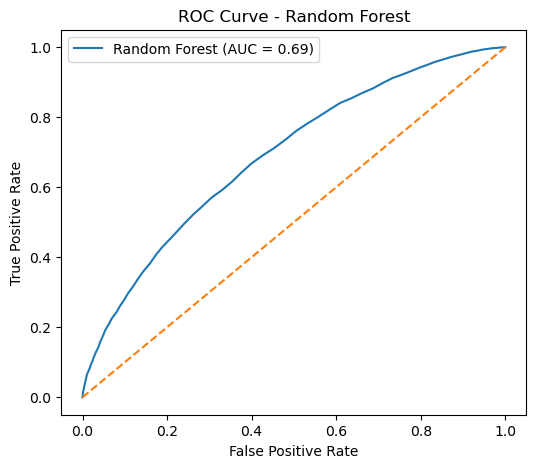

In [43]:
from sklearn.metrics import roc_curve, auc

# Probability predictions
y_prob = rf_model.predict_proba(X_test)[:,1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Random Forest (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

Feature Importance

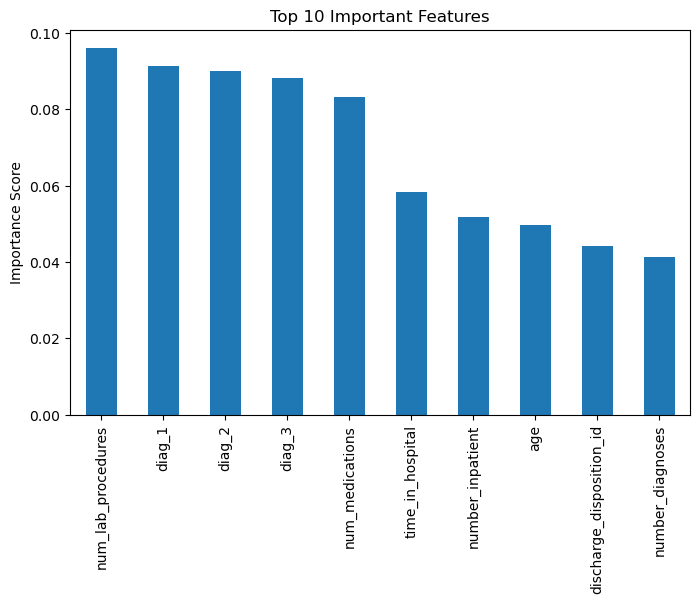

In [44]:
# Feature importance from Random Forest

importances = rf_model.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)

top_features = feature_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_features.plot(kind='bar')

plt.title("Top 10 Important Features")
plt.ylabel("Importance Score")

plt.show()

Classification report

In [45]:
classification_report(y_test, y_pred_rf)

'              precision    recall  f1-score   support\n\n           0       0.64      0.74      0.69     10952\n           1       0.63      0.52      0.57      9402\n\n    accuracy                           0.64     20354\n   macro avg       0.64      0.63      0.63     20354\nweighted avg       0.64      0.64      0.63     20354\n'

In [46]:
roc_auc

0.6899524354033745

Training accuracy for Random Forest

In [48]:
# Check training accuracy for Random Forest
train_accuracy = rf_model.score(X_train, y_train)
test_accuracy = rf_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.6383511840424486


Random Forest

In [49]:
# Random Forest with controlled complexity to reduce overfitting
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,      # limit tree depth
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Accuracy
train_accuracy = rf_model.score(X_train, y_train)
test_accuracy = rf_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.6590797425440967
Testing Accuracy: 0.6399724869804461
